#### R2P Program Unit 2: Lesson 2
# Quantum kernel estimation

In this notebook we are going to see how to use quantum kernel estimation to perform binary classification of a dataset. In particular, we will use the Quantum Support Vector Machine (QSVM), which employs quantum circuits to map data into a high-dimensional space and compute quantum kernels by measuring overlaps between quantum states. This enables expressive models for classification and can reveal complex patterns that classical methods may miss. QSVM represents a key application of quantum machine learning for supervised learning tasks.

## Outline

This notebook consists of three parts:

1. First, we will compute the quantum kernel of a single kernel matrix entry for data with relatively few features, so that we can easily follow what is happening at each step.
2. Second, we will compute the quantum kernel of an entire data set with relatively few features, so that we can see how the quantum workflow connects with classical machine learning methods.
3. Finally, we will compute the quantum kernel of two data points with a larger number of features on real hardware.

## Install required packages

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


## Read data set

We are going to read the data set corresponding to the generic binary classification problem on homogeneous spaces, see [Glick et al.](https://www.nature.com/articles/s41567-023-02340-9), of data with 14 different features and a final label (-1 or 1) in the 14th column. We can think of them as data points being pink (-1) or blue (1).

In [1]:
import pandas as pd

# Download data set
#!curl -O https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv

df = pd.read_csv("Data/dataset_graph7.csv", sep=",", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-0.193574,0.113979,-0.005927,0.300957,-0.358603,-0.087866,-0.156226,0.342442,-0.016003,0.143113,0.256422,-0.164125,-0.136743,0.014674,1.0
1,-0.100006,0.002431,0.244218,0.126870,-0.063891,-0.085588,0.072490,0.042986,-0.052714,0.019754,-0.159314,-0.409991,-0.199615,0.053845,-1.0
2,-1.774448,-0.047642,-0.025880,0.252708,-0.350689,-1.604509,-0.114874,0.347631,0.059501,-0.168956,0.351014,-0.128586,0.098897,-0.047799,1.0
3,-0.211585,-0.043782,-1.560226,0.018510,-0.051867,-0.128508,0.218609,-0.075632,-0.183656,-1.715292,-0.105361,-0.300758,-0.566431,0.046542,-1.0
4,-0.105965,0.208387,-0.003896,0.163816,-0.332541,-1.594675,-1.889321,-0.251937,0.374445,-1.431062,0.290588,0.118851,0.048799,-0.073023,1.0


## Single kernel matrix entry


A single kernel matrix entry measures the similarity between two quantum-encoded data points using the fidelity of their quantum states:

$$
K(x, y) = |\langle \phi(x) | \phi(y) \rangle|^2.
$$

We refer the reader to [this tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-kernel-training) to learn more about quantum kernels.

### Step 1: Map classical inputs to a quantum problem

Let's look at the first two data points, which is the minimal needed for calculating the kernel matrix.

![quantum_kernel](https://quantum.cloud.ibm.com/assets-docs-learning/_next/image?url=%2Flearning%2Fimages%2Fcourses%2Fquantum-machine-learning%2Fquantum-kernel-methods%2Fclassical-review-background-kernel-circuit.avif&w=3840&q=75)

We are interested in estimating how similar or different each state is from each other. We will do so by computing the overlap of the two quantum states generated by these data points, given by the probability $P_{|0\rangle}$.


In [ ]:
import numpy as np

# To illustrate what the shape of the data is we print the first two data points
small_data = df.iloc[:2]
small_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-0.193574,0.113979,-0.005927,0.300957,-0.358603,-0.087866,-0.156226,0.342442,-0.016003,0.143113,0.256422,-0.164125,-0.136743,0.014674,1.0
1,-0.100006,0.002431,0.244218,0.126870,-0.063891,-0.085588,0.072490,0.042986,-0.052714,0.019754,-0.159314,-0.409991,-0.199615,0.053845,-1.0


Here we see the 14 features of the two first data points and the labels 1 and -1 presented in the last column.

We can discard the labels to prepare unlabeled data suitable for computing inner products between data points.

In [3]:
# Data points with labels removed, for inner product
train_data = small_data.values[:,:-1]
train_data

array([[-0.19357448,  0.11397916, -0.00592673,  0.30095717, -0.35860336,
        -0.08786632, -0.15622592,  0.3424416 , -0.01600324,  0.1431133 ,
         0.25642247, -0.16412547, -0.13674259,  0.01467435],
       [-0.10000625,  0.00243083,  0.24421757,  0.12686991, -0.06389124,
        -0.085588  ,  0.07249021,  0.04298629, -0.0527142 ,  0.01975425,
        -0.15931417, -0.40999085, -0.19961527,  0.05384521]])

We create a feature map with the shape of the data points. In particular, we make use of the [`z_feature_map`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.z_feature_map) to encode the features of our data points as phase angles in the $P$ gates presented below. 

Note: The `reps` parameter in [`z_feature_map`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.z_feature_map) controls how many times the encoding block is applied. Increasing it makes the circuit more expressive, but also deeper. By default, this parameter is set to `reps = 2`.

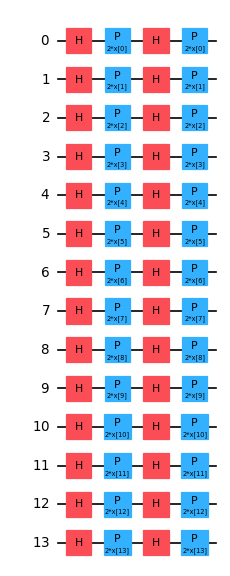

In [5]:
from qiskit.circuit.library import z_feature_map

# Create the feature map using the new function
fm = z_feature_map(feature_dimension=np.shape(train_data)[1])
# Visualize the circuit
fm.draw("mpl", scale=0.6)

We create a quantum circuit that encodes the two quantum states to compute the quantum kernel. Specifically, we use [`unitary_overlap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.unitary_overlap) to compute the overlap between the two unitaries $U_2^\dagger U_1$, computing the fidelity: 

$$
\left| \langle 0 | U_2^\dagger U_1 | 0 \rangle \right|^2,
​
$$
where $U_1$ and $U_2$ represent the quantum states 1 and 2 in `train_data`.

Note: If the two data points are identical, then $U_2^\dagger U_1 = I$, and the system returns to the state $|0\rangle$. If they are different, the cancellation is not complete, and the amplitude associated with the all-zero state is $ \langle 0 | U_2^\dagger U_1 | 0 \rangle, $, and its squared magnitude gives the value of the quantum kernel (i.e., the fidelity).



circuit depth =  9


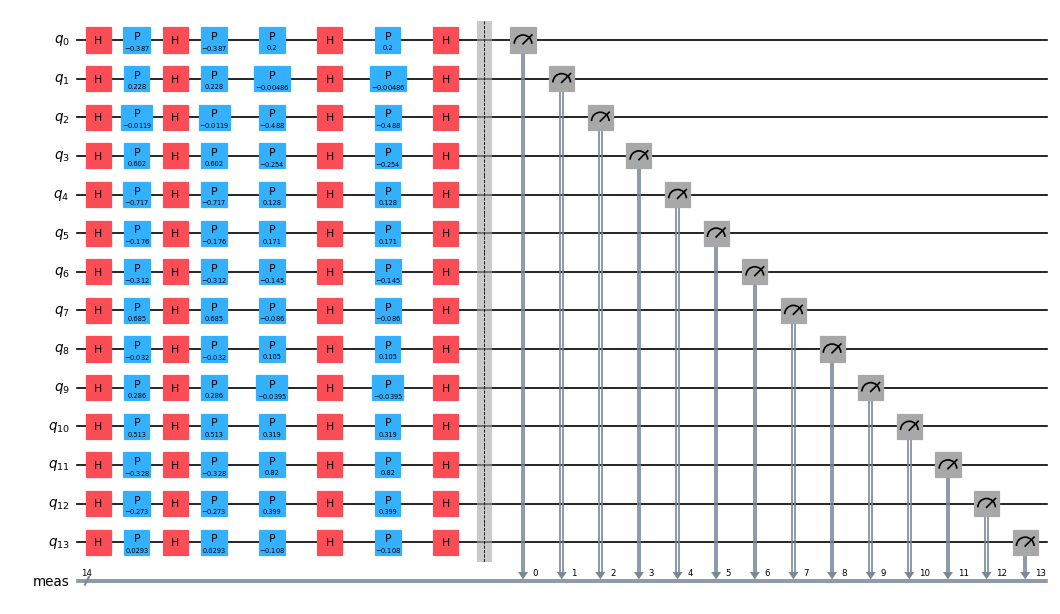

In [6]:
from qiskit.circuit.library import unitary_overlap

unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.draw("mpl", scale=0.6)

### Step 2: Optimize the problem for quantum execution

We start by selecting the least busy backend, then optimize our circuit for running on that backend.

In [ ]:
# Import needed packages
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend
service = QiskitRuntimeService()

backend = service.least_busy(min_num_qubits=127) # You can change the backend

print(backend)

management.get:WARNING:2025-10-24 14:29:42,067: Loading default saved account


<IBMBackend('ibm_brisbane')>


In [8]:
# Apply level 3 optimization to our overlap circuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

Using `optimization_level`=3 applies transpilation strategies that reduce redundant gate operations and the overall circuit depth when compiling to the backend's native gate set.

Note: After transpilation, Qiskit rewrites the circuit using the hardware’s native basis gates, such as $ R_X$ and $\sqrt{X}\;(\mathrm{SX})$. This means the original gates are decomposed into operations that are directly supported by the selected backend.


circuit depth =  6
0


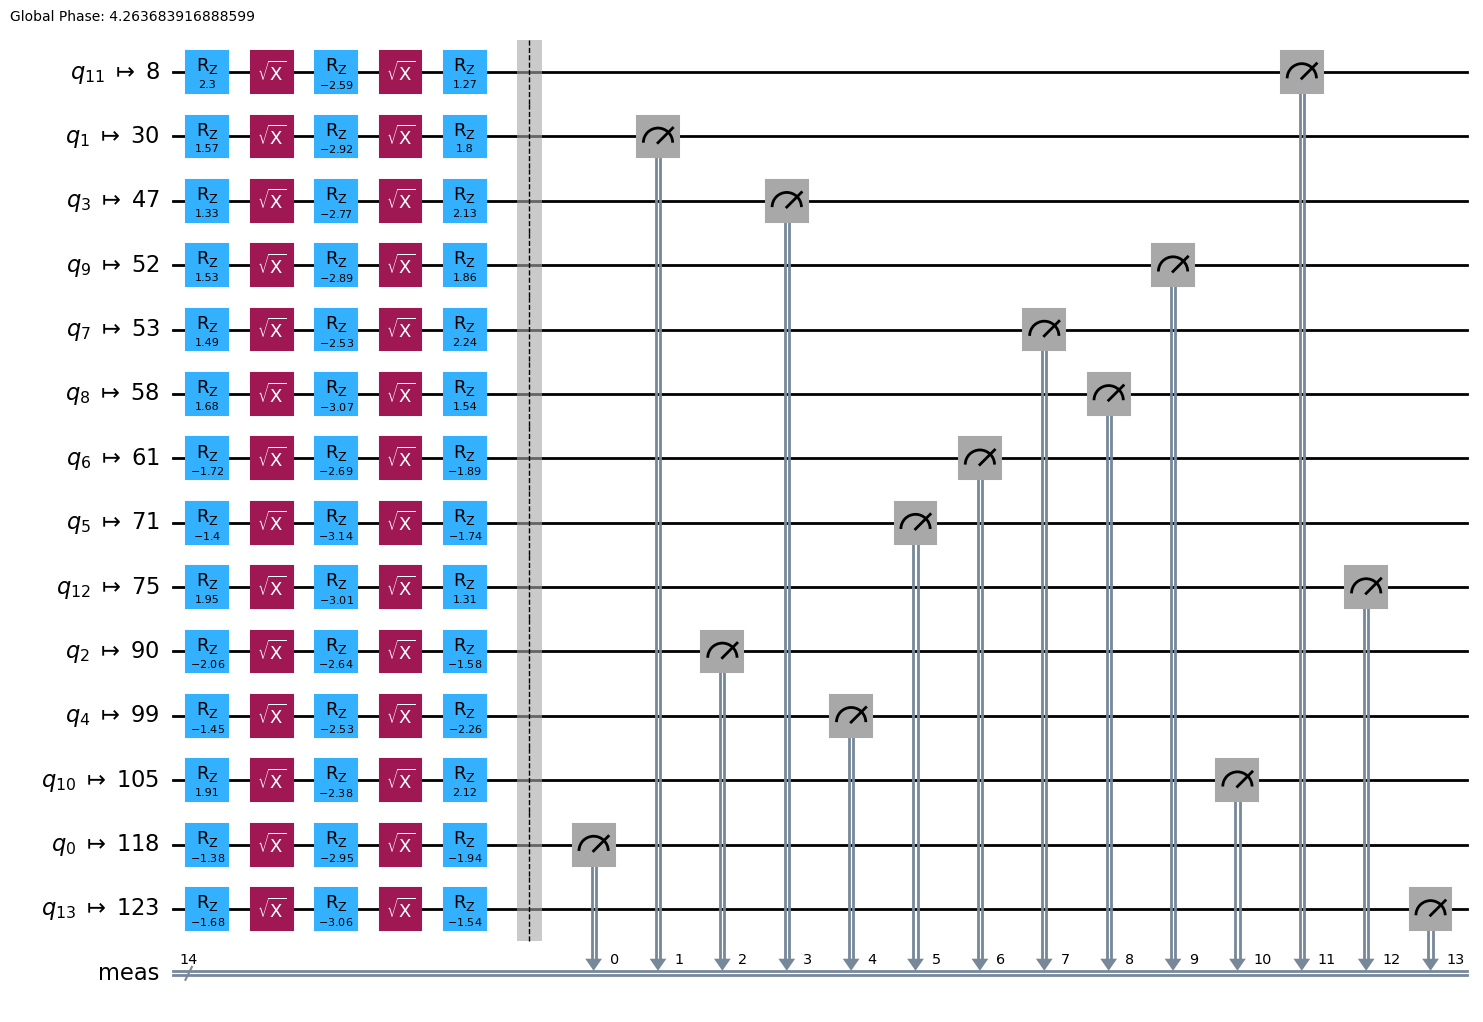

In [9]:
print("circuit depth = ", overlap_ibm.depth())
print(f"{overlap_ibm.depth(lambda x: x.operation.num_qubits == 2)}")
overlap_ibm.draw(output="mpl",idle_wires=False)

### Step 3: Execute using Qiskit Runtime Primitives

We execute this code on a statevector simulator.

In [11]:
# Run this for a simulator
from qiskit.primitives import StatevectorSampler

num_shots = 10000

# Evaluate the problem using state vector-based primitives from Qiskit
sampler = StatevectorSampler()
job = sampler.run([overlap_circ], shots=num_shots)
results = job.result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()

### Step 4: Post-process, return result in classical format

As described in the introduction, the quantum kernel estimation we are looking for is the probability $P_{|0\rangle}$ of measuring the all zero state $∣000...00\rangle$. This probability corresponds to the overlap between quantum states prepared from different data points, providing a measure of their similarity.

In [12]:
counts_bit.get('0'*len(train_data[0]))/num_shots

0.5499

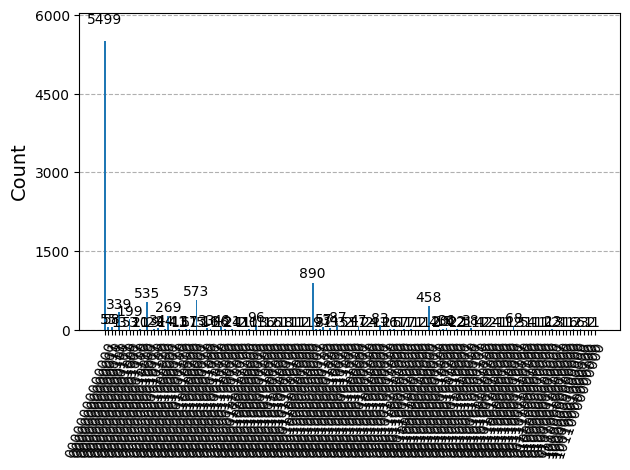

In [13]:
from qiskit.visualization import plot_histogram
plot_histogram(counts_bit)

It's hard to read with too many bitstrings. Let's use the following functions to show the top 10 bitstrings.

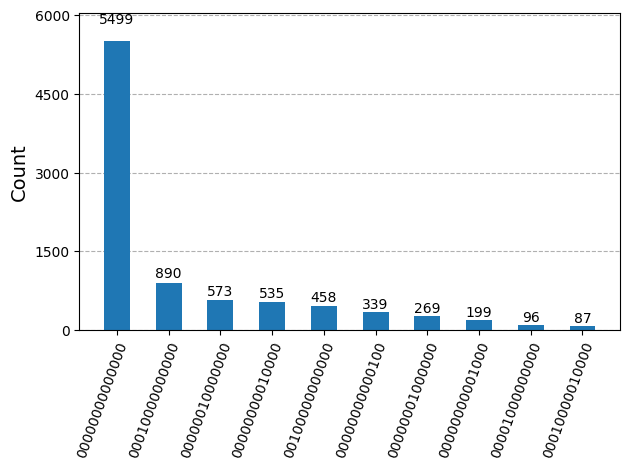

In [14]:
plot_histogram(data=counts_bit, sort='value_desc', number_to_keep=10)

## Full kernel matrix and QSVM

Now that we have seen a simple example of computing the quantum kernel between two data points, which tells us how similar or different they are, we can move on to calculating the full kernel matrix for all pairs in the dataset. Once the matrix is computed, we can apply the QSVM algorithm to perform binary classification. QSVMs use the kernel trick to implicitly map inputs into a high-dimensional feature space, where a linear decision boundary (a hyperplane) can separate the data into two groups.

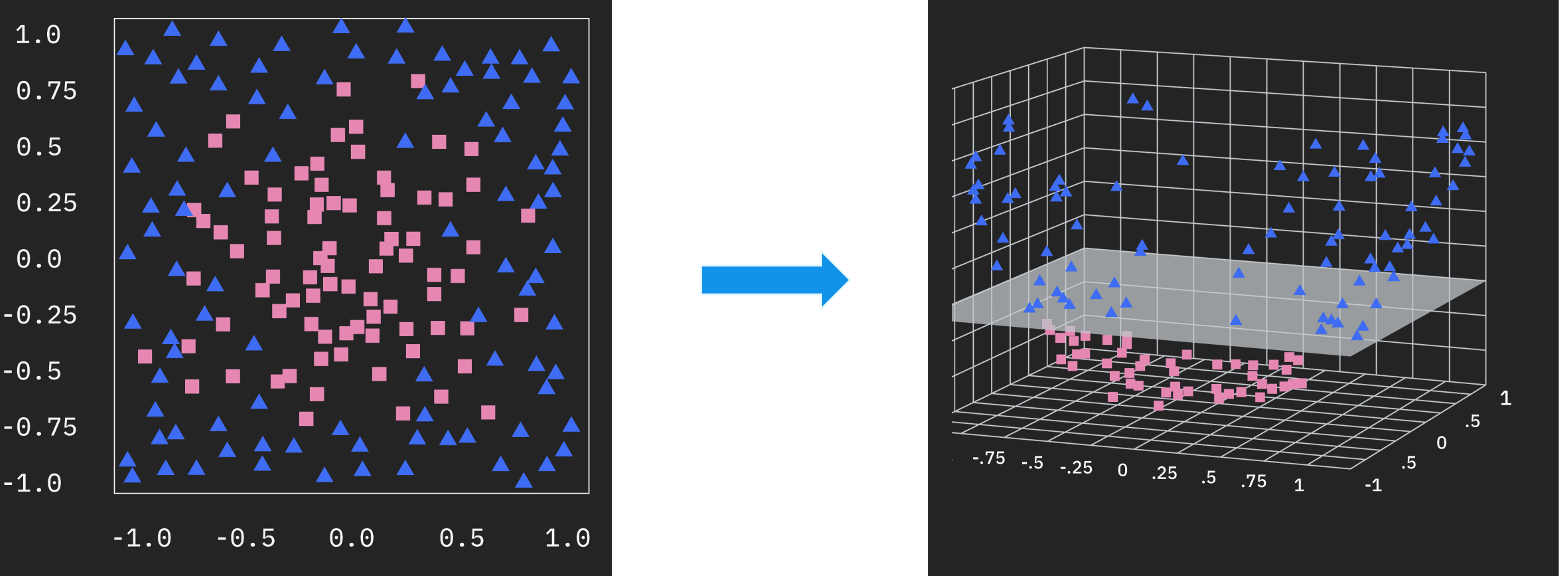


### Step 1: Map classical inputs to a quantum problem

In [15]:
# Total number of data points in this data set
len(df)

128

As it is usually done in classical Machine Learning, we divide the dataset into training and testing sets to evaluate how well the model generalizes to unseen data and to prevent overfitting.

In [16]:
# Prepare training data
train_size = 30
X_train=df.values[0:train_size,:-1]
train_labels = df.values[0:train_size,-1]

# Prepare testing data
test_size = 10
X_test=df.values[train_size:train_size+test_size,:-1]
test_labels=df.values[train_size:train_size+test_size,-1]

In [17]:
# Create an empty kernel matrix with the shape of the training data
kernel_matrix = np.full((train_size, train_size),0)
print("Kernel matrix shape:", kernel_matrix.shape)
# Create empty test matrix
test_matrix = np.full((test_size, train_size), 0)
print("Test matrix shape:", test_matrix.shape)

Kernel matrix shape: (30, 30)
Test matrix shape: (10, 30)


In [18]:
from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit

# Prepare feature map for computing overlap
num_features = np.shape(X_train)[1]
num_qubits = int(num_features / 2)
print(f"Number of features: {num_features}")
print(f"Number of qubits: {num_qubits}")

Number of features: 14
Number of qubits: 7


We define a custom feature map that includes the encoding of the data `x` using $R_Z$ and $R_X$ gates and the variational parameters `θ` included in $R_Y$ gates. Also, we are encoding two features per qubit which means that we only need 7 qubits to encode the 14 features per data point.

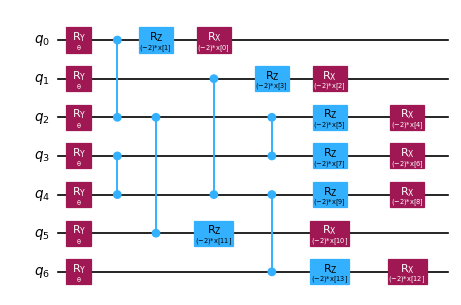

In [ ]:
entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]

fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)

fm.draw("mpl", scale=0.6)

### Step 2 & 3: Optimize the problem & execute using primitives

Each training circuit computes one entry of the kernel matrix, which measures the similarity between two data points encoded as quantum states. Since the kernel matrix compares all pairs in the training set, we need many circuits, each one corresponding to a specific pair. The input data (X_train) provides a list of data points with the classical features that are mapped to quantum states, and the resulting matrix entries reflect how close these states are to each other.

In [20]:
# Create training circuit lists
def create_training_overlap_circuit_list(train_size, X_train, feature_map):
    training_overlap_circ_list = [
        unitary_overlap(
            feature_map.assign_parameters(list(X_train[x1]) + [np.pi / 2]),
            feature_map.assign_parameters(list(X_train[x2]) + [np.pi / 2])
        )
        for x1 in range(train_size) for x2 in range(x1 + 1, train_size)
    ]

    for circuit in training_overlap_circ_list:
        circuit.measure_all()

    return training_overlap_circ_list

# Create testing circuit lists computing overlaps between test and train data
def create_testing_overlap_circuit_list(test_size, train_size, X_test, X_train, feature_map):
    testing_overlap_circ_list = [
        unitary_overlap(
            feature_map.assign_parameters(list(X_test[x1]) + [np.pi / 2]),
            feature_map.assign_parameters(list(X_train[x2]) + [np.pi / 2])
        )
        for x1 in range(test_size) for x2 in range(train_size)
    ]

    for circuit in testing_overlap_circ_list:
        circuit.measure_all()

    return testing_overlap_circ_list


def compute_overlap_matrix(results, size1, size2, is_symmetric=False):
    """
    Compute the kernel or test matrix from the sampler results.

    Parameters:
    - results: The result object from sampler.run()
    - size1: Number of rows in the matrix (train_size or test_size)
    - size2: Number of columns in the matrix (train_size)
    - is_symmetric: If True, fills a symmetric kernel matrix.

    Returns:
    - A numpy array representing the computed overlap matrix.
    """
    overlap_matrix = np.zeros((size1, size2))
    idx = 0

    for x1 in range(size1):
        for x2 in range(x1 + 1, size2) if is_symmetric else range(size2):
            counts = results[idx].data.meas.get_int_counts()
            prob_0 = counts.get(0, 0.0) / num_shots

            overlap_matrix[x1, x2] = prob_0

            if is_symmetric:
                overlap_matrix[x2, x1] = prob_0  # Mirror value for symmetry

            idx += 1

        if is_symmetric:
            overlap_matrix[x1, x1] = 1  # Diagonal elements should be 1 for training data

    return overlap_matrix

In [21]:
# Evaluate the problem using state vector-based primitives from Qiskit.
sampler = StatevectorSampler()
num_shots = 10000

Create training circuits and submit job.

In [22]:
training_overlap_circ_list = create_training_overlap_circuit_list(train_size, X_train, fm)
job_training = sampler.run(training_overlap_circ_list, shots=num_shots)

Create testing circuits and submit job.

In [23]:
testing_overlap_circ_list = create_testing_overlap_circuit_list(test_size, train_size, X_test, X_train, fm)
job_testing = sampler.run(testing_overlap_circ_list, shots=num_shots)

Compute the training kernel matrix.

In [24]:
results_training = job_training.result()
kernel_matrix = compute_overlap_matrix(results_training, train_size, train_size, is_symmetric=True)
print("Training matrix done")

Training matrix done


We visualize a 10x10 subset of the training matrix.

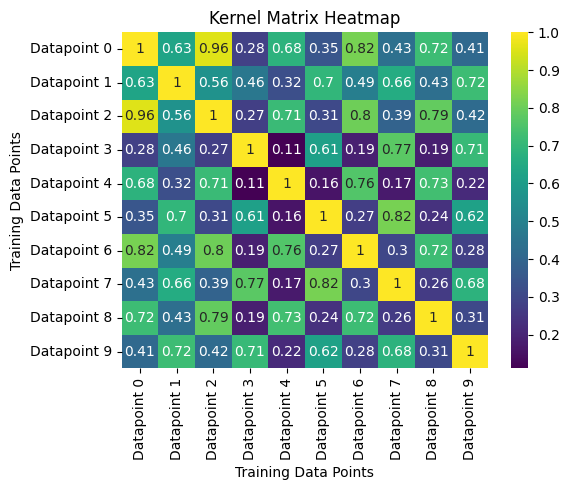

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

subset=10
labels = [f"Datapoint {i}" for i in range(kernel_matrix[:subset].shape[0])]
# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(kernel_matrix[:subset,:subset], annot=True, cmap='viridis', xticklabels=labels, yticklabels=labels)
plt.title("Kernel Matrix Heatmap")
plt.xlabel("Training Data Points")
plt.ylabel("Training Data Points")
plt.tight_layout()
plt.show()

Compute the test matrix.

In [26]:
results_testing = job_testing.result()
test_matrix = compute_overlap_matrix(results_testing, test_size, train_size, is_symmetric=False)
print("Test matrix done")

Test matrix done


We visualize a 10x10 subset of the test matrix.

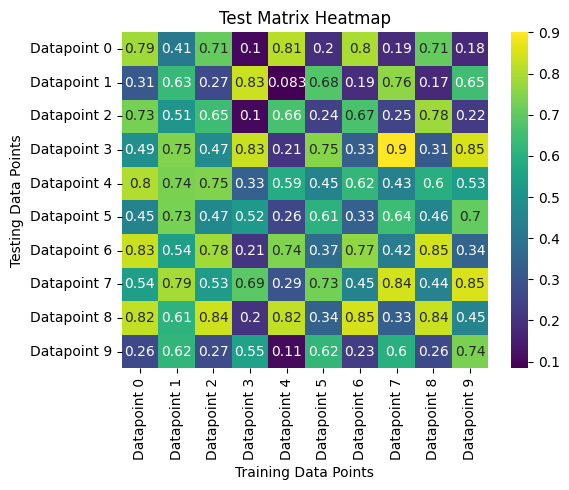

In [27]:
subset=10
labels = [f"Datapoint {i}" for i in range(test_matrix [:subset].shape[0])]
# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(test_matrix [:subset,:subset], annot=True, cmap='viridis', xticklabels=labels, yticklabels=labels)
plt.title("Test Matrix Heatmap")
plt.xlabel("Training Data Points")
plt.ylabel("Testing Data Points")
plt.tight_layout()
plt.show()


#### Running on real hardware

Uncomment the next cell if you want to execute this on hardware.

*The approximate runtime on IBM Kingston was 31 min and 45 seconds.*


In [ ]:
# Running on real hardware

#from qiskit_ibm_runtime import SamplerV2 as Sampler
#sampler = Sampler(mode=backend)

# Create the circuits for training and testing overlaps

#training_overlap_circ_list = create_training_overlap_circuit_list(train_size, X_train, fm)
#pm = generate_preset_pass_manager(optimization_level=2, backend=backend)
#isa_circuit_list = [pm.run(circuit) for circuit in training_overlap_circ_list]
#job_training = sampler.run(isa_circuit_list, shots=num_shots)

#testing_overlap_circ_list = create_testing_overlap_circuit_list(test_size, train_size, X_test, X_train, fm)
#isa_circuit_list = [pm.run(circuit) for circuit in testing_overlap_circ_list]
#job_testing = sampler.run(isa_circuit_list, shots=num_shots)

# Compute training and testing matrix

#results_training = job_training.result()
#kernel_matrix = compute_overlap_matrix(results_training, train_size, train_size, is_symmetric=True)
#print("Training matrix done")

#results_testing = job_testing.result()
#test_matrix = compute_overlap_matrix(results_testing, test_size, train_size, is_symmetric=False)
#print("Test matrix done")

### Step 4: Post-process, return result in classical format

Apply the Support Vector Machine (SVM) using as its kernel function the quantum kernel matrix, which encodes the similarity between data points, to implement a Quantum Support Vector Machine (QSVM).

In [29]:
# import a support vector classifier from a classical ML package.
from sklearn.svm import SVC
#Specify that you want to use a pre-computed kernel matrix
qml_svc = SVC(kernel="precomputed")

Train the model

In [30]:
# Fit the model using the quantum kernel matrix
qml_svc.fit(kernel_matrix, train_labels)

SVC(kernel='precomputed')

Let us now compare the predictions of the QSVM with the `test_labels`

In [31]:
print("QSVM predictions", qml_svc.predict(test_matrix))
print("Test labels", test_labels)

QSVM predictions [ 1. -1.  1. -1.  1. -1.  1. -1.  1. -1.]
Test labels [ 1. -1.  1. -1.  1. -1.  1. -1.  1. -1.]


In [32]:
# Now use the .score to test your data, using the matrix of test data, and test labels as your inputs.
qml_score_precomputed_kernel = qml_svc.score(test_matrix, test_labels)
print(f"Precomputed kernel classification test score: {qml_score_precomputed_kernel}")

Precomputed kernel classification test score: 1.0


# Conclusion

In this notebook, we have seen how we can use quantum kernels to perform binary classification with a high degree of accuracy in classifying data points as pink (-1) or blue (1). Applying the QSVM allowed us to leverage the expressive power of high-dimensional Hilbert spaces to separate data into two classes. While this example focused on binary classification, the QSVM framework can be extended to multiclass problems, which may present greater challenges for classical kernel methods. Exploring these extensions offers a promising direction for continuing to evaluate the capabilities of quantum machine learning as quantum hardware advances.


## Further reading

If you want to learn more about Quantum Machine Learning, check out [the QML course](https://learning.quantum.ibm.com/course/quantum-machine-learning) on the IBM Quantum Learning platform.

Below we have an example of the computation of a quantum kernel between two mock data points with a relatively larger number of features than the examples above.

### Step 1: Map classical inputs to a quantum problem

We consider two mock data points, including category labels, as we did before.

In [9]:

large_data = [
    [-0.028,	-1.49,	-1.698,	0.107,	-1.536,	-1.538,	-1.356,	-1.514,	-0.109,	-1.8,	-0.122,	-1.651,	-1.955,	-0.123,	-1.732,	0.091,	-0.048,	-0.128,	-0.026,	0.082,	-1.263,	0.065,	0.004,	-0.055,	-0.08,	-0.173,	-1.734,	-0.39,	-1.451,	0.078,	-1.578,	-0.025,	-0.184,	-0.119,	-1.336,	0.055,	-0.204,	-1.578,	0.132,	-0.121,	-1.599,	-0.187,-1],
    [-1.414,	-1.439,	-1.606,	0.246,	-1.673,	0.002,	-1.317,	-1.262,	-0.178,	-1.814,	0.013,	-1.619,	-1.86,	-0.25,	-0.212,	-0.214,	-0.033,	0.071,	-0.11,	-1.607,	0.441,	-0.143,	-0.009,	-1.655,	-1.579,	0.381,	-1.86,	-0.079,	-0.088,	-0.058,	-1.481,	-0.064,	-0.065,	-1.507,	0.177,	-0.131,	-0.153,	0.07,	-1.627,	0.593,	-1.547,	-0.16,-1]
]
train_data = [large_data[0][:-1],large_data[1][:-1]]
print(len(train_data[0]))

42


We define the unitaries and build the quantum circuit to measure the overlap using, the [`zz_feature_map`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.zz_feature_map) to encode the features of our data points as phase angles and pairwise $ZZ$ entangling interactions between qubits.

Note: The `entanglement` parameter specifies how qubits are entangled (e.g., `"full"`, `"linear"`), which determines the pattern of $ZZ$ interactions between features.


In [34]:
from qiskit.circuit.library import zz_feature_map

fm = zz_feature_map(feature_dimension=np.shape(train_data)[1], entanglement='linear', reps=1)
unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])
overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose(reps = 2).depth())
print("two-qubit depth", overlap_circ.decompose().depth(lambda instr: len(instr.qubits) > 1))

circuit depth =  251
two-qubit depth 165


We design a custom feature map with a customized entanglement map to reduce the circuit depth and two-qubit depth.

In [35]:
# Prepare feature map for computing overlap
entangler_map = [    [3, 4], [2, 5], [1, 4], [2, 3], [4, 6], [7, 9], [10, 11], [9, 12], [8, 11], [9, 10], [11, 13], [14, 16], [17, 18], [16, 19], [15, 18], [16, 17], [18, 20]
]

num_features = np.shape(train_data)[1]
num_qubits = int(num_features / 2)

fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)

# Assign features of each data point to a unitary, an instance of the general feature map.
unitary1 = fm.assign_parameters(list(train_data[0])+ [np.pi / 2] )
unitary2 = fm.assign_parameters(list(train_data[1])+ [np.pi / 2] )

# Create the overlap circuit
overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

print("circuit depth = ", overlap_circ.decompose(reps = 2).depth())
print("two-qubit depth", overlap_circ.decompose().depth(lambda instr: len(instr.qubits) > 1))

circuit depth =  23
two-qubit depth 7


### Step 2: Optimize problem for quantum execution

In [ ]:
service = QiskitRuntimeService()
backend = service.least_busy(min_num_qubits=127)

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)
print("circuit depth = ", overlap_ibm.decompose().depth())

management.get:WARNING:2025-10-24 14:30:03,423: Loading default saved account


circuit depth =  59


### Step 3: Execute using Qiskit Runtime Primitives

In [37]:
num_shots = 10000
# Use sampler and get the counts
from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(mode=backend)
options = sampler.options
options.dynamical_decoupling.enable = True
options.twirling.enable_gates = True
counts = (
        sampler.run([overlap_ibm], shots=num_shots).result()[0].data.meas.get_int_counts()
        )

### Step 4: Post-process, return result in classical format

Here we see $P_0$, the probability of measuring the all-zero state, which reflects the overlap between the two mock data points encoded in the circuit. It will also constitute a single kernel matrix entry.

In [38]:
counts.get(0, 0.0)/num_shots

0.0119

If we had more data points we could calculate the full kernel matrix as we have done in the example above.